### Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("sales_forecasting_dataset.csv")

In [3]:
df.head()

,date,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,is_holiday,...,temperature,precipitation,gdp_growth,unemployment_rate,consumer_confidence,marketing_spend,website_visits,social_media_engagement,customer_footfall,sales
0,2010-01-01,2010,1,1,4,1,53,1,0,1,...,59.87,2.03,2.22,6.08,62.38,616.92,1335,605,573,89.29
1,2010-01-02,2010,1,2,5,2,53,1,1,0,...,57.54,3.61,2.68,5.89,65.68,782.26,1337,647,464,62.44
2,2010-01-03,2010,1,3,6,3,53,1,1,0,...,58.80,1.17,2.96,5.91,65.72,568.46,1076,447,458,57.88
3,2010-01-04,2010,1,4,0,4,1,1,0,0,...,63.68,4.67,2.53,5.81,62.54,433.05,1225,486,221,31.04
4,2010-01-05,2010,1,5,1,5,1,1,0,0,...,57.52,9.94,2.41,5.70,69.16,412.71,1112,440,340,43.76


In [4]:
df.shape

(5000, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     5000 non-null   object 
 1   year                     5000 non-null   int64  
 2   month                    5000 non-null   int64  
 3   day                      5000 non-null   int64  
 4   day_of_week              5000 non-null   int64  
 5   day_of_year              5000 non-null   int64  
 6   week_of_year             5000 non-null   int64  
 7   quarter                  5000 non-null   int64  
 8   is_weekend               5000 non-null   int64  
 9   is_holiday               5000 non-null   int64  
 10  store_id                 5000 non-null   int64  
 11  store_name               5000 non-null   object 
 12  category_id              5000 non-null   int64  
 13  product_category         5000 non-null   object 
 14  product_subcategory     

In [6]:
df.isnull().sum()

date                       0
year                       0
month                      0
day                        0
day_of_week                0
day_of_year                0
week_of_year               0
quarter                    0
is_weekend                 0
is_holiday                 0
store_id                   0
store_name                 0
category_id                0
product_category           0
product_subcategory        0
base_price                 0
discount_percentage        0
is_promotion               0
price                      0
stock_level                0
competitor_price           0
temperature                0
precipitation              0
gdp_growth                 0
unemployment_rate          0
consumer_confidence        0
marketing_spend            0
website_visits             0
social_media_engagement    0
customer_footfall          0
sales                      0
dtype: int64

There are not null value in a dataset


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5000.0,2016.352800,3.954827,2010.00,2013.0000,2016.000,2020.0000,2023.00
month,5000.0,6.430600,3.427584,1.00,3.0000,6.000,9.0000,12.00
day,5000.0,15.708400,8.804753,1.00,8.0000,16.000,23.0000,31.00
day_of_week,5000.0,3.000600,2.000050,0.00,1.0000,3.000,5.0000,6.00
day_of_year,5000.0,180.262200,104.776875,1.00,90.0000,179.000,270.0000,366.00
week_of_year,5000.0,26.185000,14.971854,1.00,13.0000,26.000,39.0000,53.00
quarter,5000.0,2.479200,1.110592,1.00,1.0000,2.000,3.0000,4.00
is_weekend,5000.0,0.285800,0.451840,0.00,0.0000,0.000,1.0000,1.00
is_holiday,5000.0,0.026400,0.160338,0.00,0.0000,0.000,0.0000,1.00
store_id,5000.0,3.045400,1.421599,1.00,2.0000,3.000,4.0000,5.00


In [8]:
df.nunique()

date                       5000
year                         14
month                        12
day                          31
day_of_week                   7
day_of_year                 366
week_of_year                 53
quarter                       4
is_weekend                    2
is_holiday                    2
store_id                      5
store_name                    5
category_id                   5
product_category              5
product_subcategory          18
base_price                 3540
discount_percentage           7
is_promotion                  2
price                      3705
stock_level                 450
competitor_price           4174
temperature                3209
precipitation              1424
gdp_growth                  250
unemployment_rate           206
consumer_confidence        2378
marketing_spend            4560
website_visits              807
social_media_engagement     335
customer_footfall           445
sales                      3910
dtype: i

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

#### Data Visualization


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

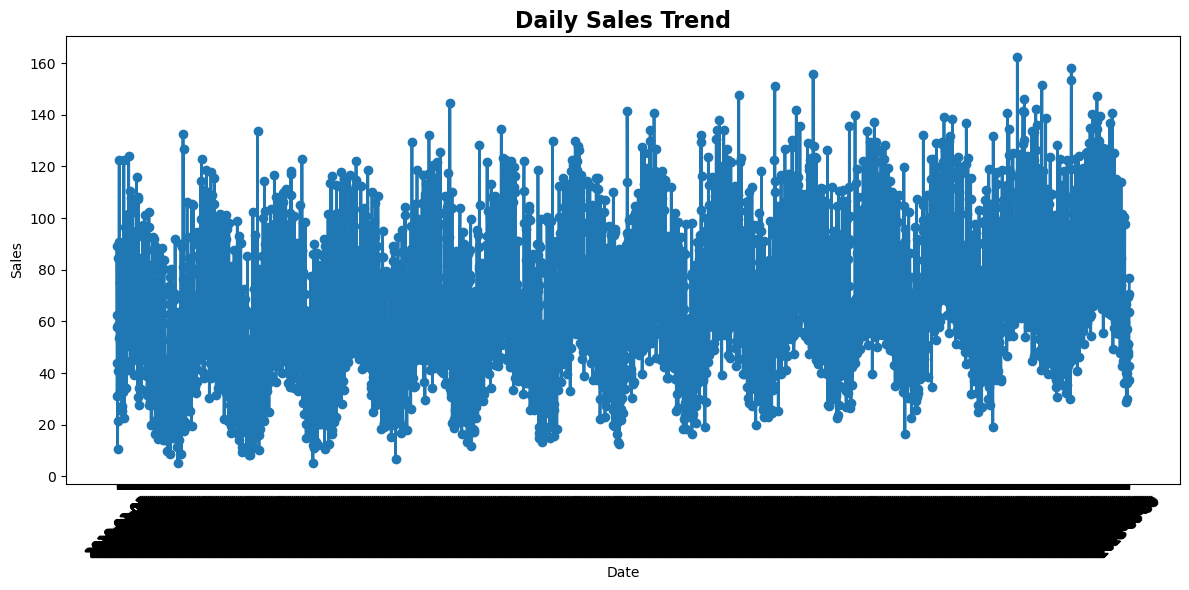

In [11]:
# 1. Sales over time (line plot)
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['sales'], marker='o', linewidth=2, markersize=6)
plt.title('Daily Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

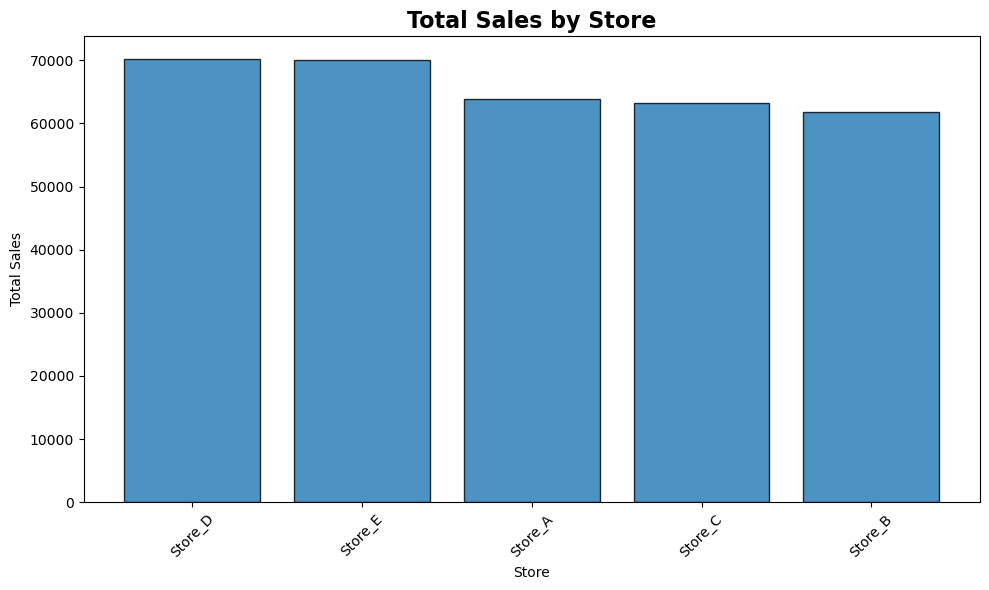

In [12]:
# 2. Sales by Store (bar plot)
plt.figure(figsize=(10, 6))
store_sales = df.groupby('store_name')['sales'].sum().sort_values(ascending=False)
plt.bar(store_sales.index, store_sales.values, alpha=0.8, edgecolor='black')
plt.title('Total Sales by Store', fontsize=16, fontweight='bold')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

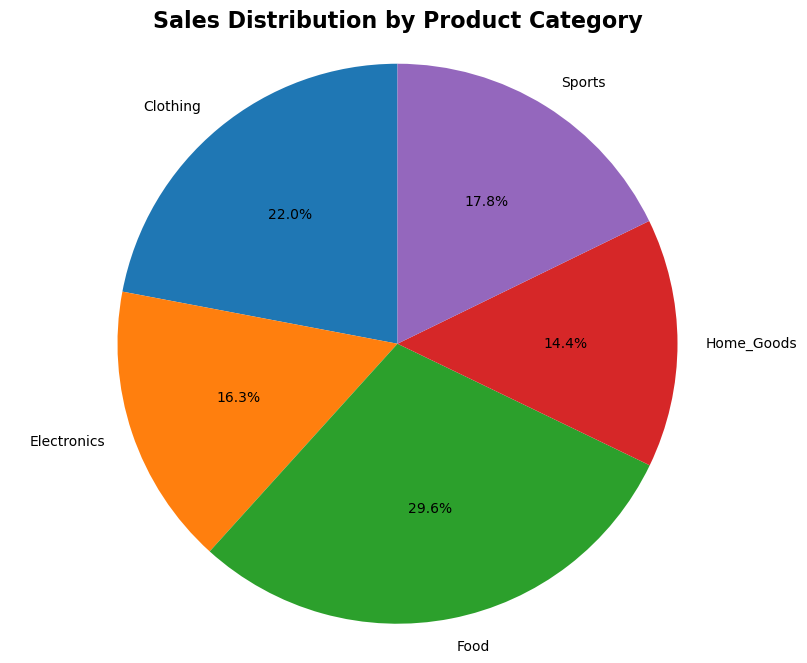

In [13]:
# 3. Sales by Product Category (pie chart)
plt.figure(figsize=(10, 8))
category_sales = df.groupby('product_category')['sales'].sum()
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Product Category', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

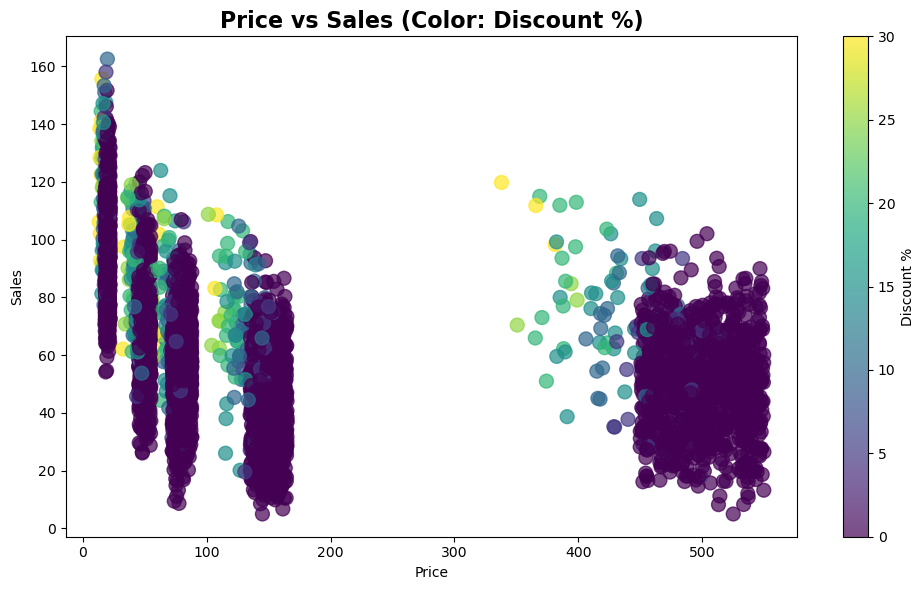

In [14]:
# 4. Price vs Sales correlation (scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['price'], df['sales'], s=100, alpha=0.7, c=df['discount_percentage'], cmap='viridis')
plt.colorbar(label='Discount %')
plt.title('Price vs Sales (Color: Discount %)', fontsize=16, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

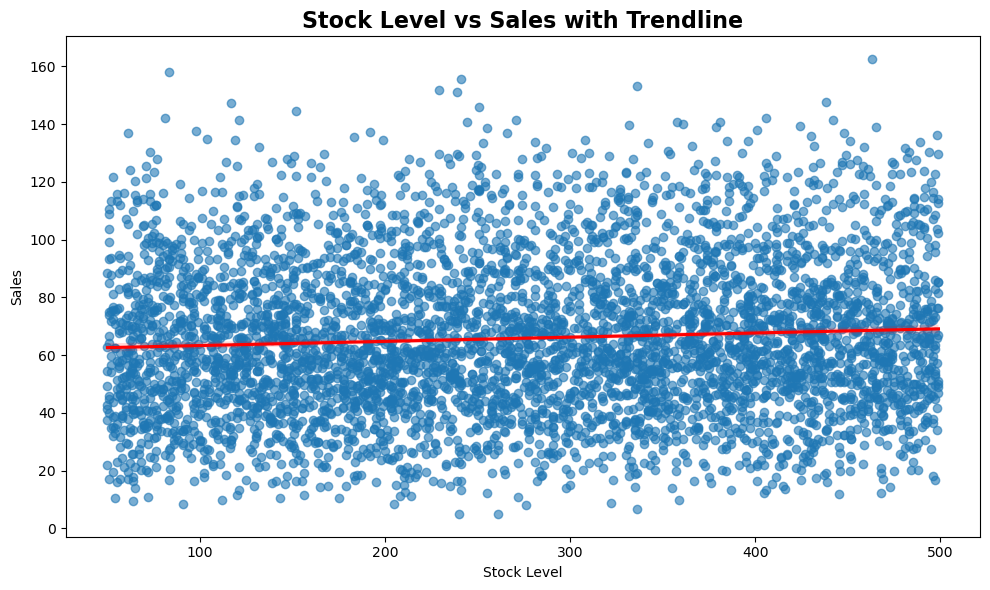

In [15]:
# 5. Stock Level vs Sales (scatter with trendline)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='stock_level', y='sales', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Stock Level vs Sales with Trendline', fontsize=16, fontweight='bold')
plt.xlabel('Stock Level')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


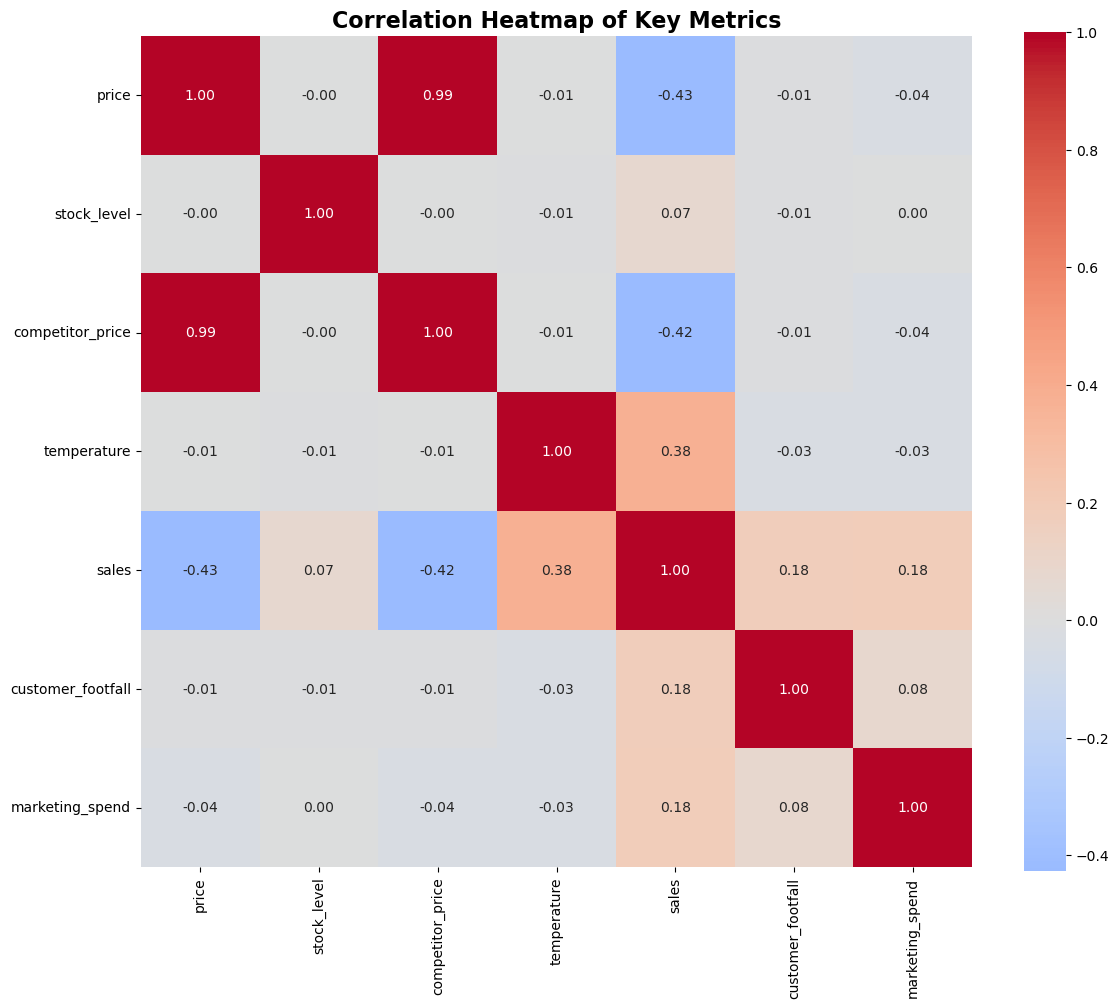

In [16]:
# 6. Multi-feature correlation heatmap
plt.figure(figsize=(12, 10))
numeric_cols = ['price', 'stock_level', 'competitor_price', 'temperature', 'sales', 'customer_footfall', 'marketing_spend']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Heatmap of Key Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

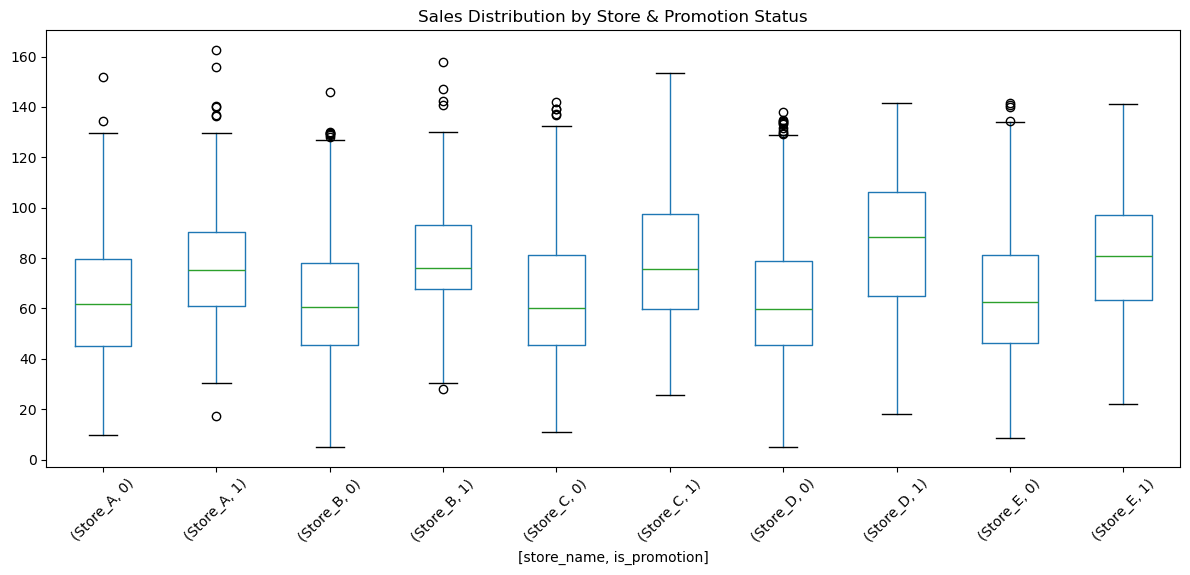

In [17]:
# 7. Box plot: Sales by Store and Promotion Status
plt.figure(figsize=(12, 6))
df.boxplot(column='sales', by=['store_name', 'is_promotion'], grid=False, figsize=(12,6))
plt.title('Sales Distribution by Store & Promotion Status')
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print("Visualizations generated successfully!")
print("\nKey Insights from data:")
print("- Store_D dominates sales across multiple categories")
print("- Higher discount % appears in high-price items")
print("- Sales correlate with customer footfall")
print("- Electronics (Laptops) have highest base price")

Visualizations generated successfully!

Key Insights from data:
- Store_D dominates sales across multiple categories
- Higher discount % appears in high-price items
- Sales correlate with customer footfall
- Electronics (Laptops) have highest base price
